# 03 — A/B Test Retention Analysis

**Objective:** Determine whether the new recommendation module (gate_40) significantly improves retention compared to the control (gate_30).

**Primary metric:** 7-day retention (`retention_7`)  
**Secondary metric:** 1-day retention (`retention_1`)  

**Steps in this notebook:**
1. Calculate retention rates for each group
2. Compute absolute and relative uplift
3. Run hypothesis tests (two-proportion z-test)
4. Compute 95% confidence intervals
5. Visualise results

**Input:** `../data/app_ab_test.db`

In [ ]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))   # allow importing from src/

import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Import reusable A/B testing functions from src/
# 从 src/ 导入封装好的 A/B 测试函数
from src.ab_testing import run_ab_test, print_ab_result

# Connect to database / 连接数据库
conn = sqlite3.connect('../data/app_ab_test.db')
df = pd.read_sql_query('SELECT * FROM users', conn)

print(f'Loaded {len(df):,} users')
df.head()

---
## 1. Retention Rates by Group
计算两组的留存率

In [ ]:
# Run full A/B test for both metrics in one call each
# 对两个指标分别调用 run_ab_test，一次性完成：留存率、uplift、z 检验、置信区间
result_d1 = run_ab_test(df, metric_col='retention_1')
result_d7 = run_ab_test(df, metric_col='retention_7')

print('=== D1 Retention ===')
print_ab_result(result_d1)
print()
print('=== D7 Retention (Primary Metric) ===')
print_ab_result(result_d7)

In [ ]:
# Extract values from results for use in visualisations below
# 从结果对象中解包变量，供后续可视化使用
rate_d1_ctrl, rate_d1_trt = result_d1.rate_ctrl, result_d1.rate_trt
rate_d7_ctrl, rate_d7_trt = result_d7.rate_ctrl, result_d7.rate_trt

diff_d1, lo_d1, hi_d1 = result_d1.abs_uplift, result_d1.ci_lower, result_d1.ci_upper
diff_d7, lo_d7, hi_d7 = result_d7.abs_uplift, result_d7.ci_lower, result_d7.ci_upper

p_d1, p_d7 = result_d1.p_value, result_d7.p_value

print('Variables unpacked for visualisation ✓')

---
## 2. Hypothesis Testing — Two-Proportion Z-Test
假设检验 — 双比例 z 检验

**Hypotheses / 假设：**
- H₀ (Null hypothesis / 零假设): p_treatment = p_control — 两组留存率没有差异
- H₁ (Alternative hypothesis / 备择假设): p_treatment ≠ p_control — 两组留存率有差异

**Decision rule / 判断规则：**
- If p-value < 0.05 → reject H₀ → 差距是真实的，统计显著
- If p-value ≥ 0.05 → fail to reject H₀ → 证据不足，差距可能是随机波动

---
## 3. Confidence Intervals
置信区间

A 95% confidence interval tells us: if we ran this experiment 100 times, the true uplift would fall within this range 95 times.

95% 置信区间的含义：如果重复做这个实验 100 次，真实的 uplift 有 95 次会落在这个范围内。

---
## 4. Visualisation
可视化

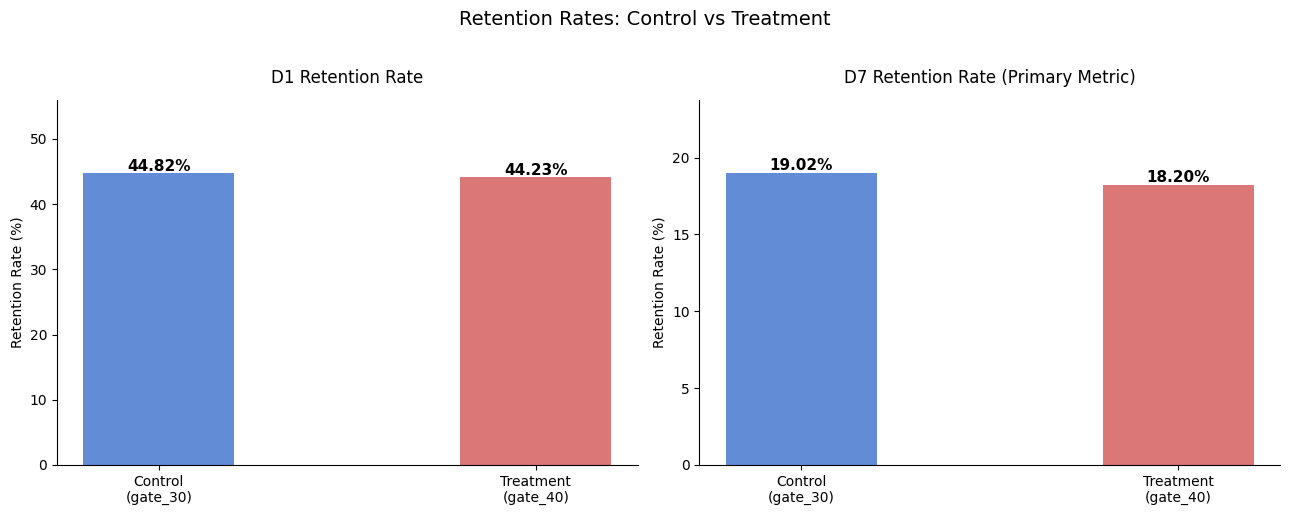

Figure saved ✓


In [6]:
# Chart 1: Retention rate comparison bar chart
# 图1：D1 和 D7 留存率对比柱状图

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ['#4878CF', '#D65F5F']  # blue = control, red = treatment

for ax, ctrl_rate, trt_rate, title in zip(
    axes,
    [rate_d1_ctrl, rate_d7_ctrl],
    [rate_d1_trt,  rate_d7_trt],
    ['D1 Retention Rate', 'D7 Retention Rate (Primary Metric)']
):
    bars = ax.bar(
        ['Control\n(gate_30)', 'Treatment\n(gate_40)'],
        [ctrl_rate * 100, trt_rate * 100],
        color=colors, width=0.4, alpha=0.85
    )
    # Add value labels on each bar / 在柱子上标注数值
    for bar, val in zip(bars, [ctrl_rate, trt_rate]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.2,
                f'{val:.2%}', ha='center', fontsize=11, fontweight='bold')
    ax.set_title(title, fontsize=12, pad=12)
    ax.set_ylabel('Retention Rate (%)')
    ax.set_ylim(0, max(ctrl_rate, trt_rate) * 100 * 1.25)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Retention Rates: Control vs Treatment', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/03_retention_rates.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved ✓')

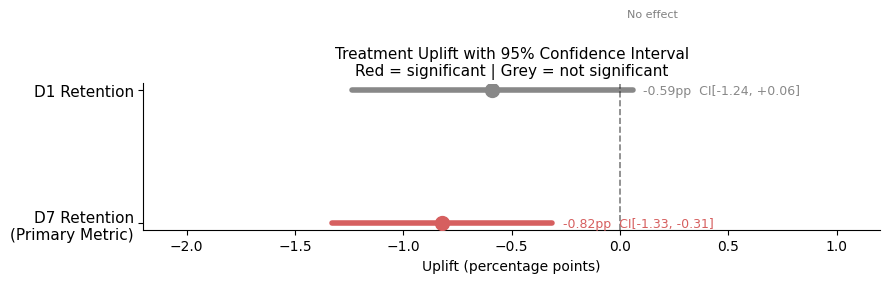

Figure saved ✓


In [7]:
# Chart 2: Uplift with 95% confidence interval
# 图2：Uplift + 95% 置信区间
# CI that does NOT cross 0 = statistically significant
# 不跨过 0 的 CI = 统计显著；跨过 0 = 不显著

fig, ax = plt.subplots(figsize=(9, 3.5))

metrics = ['D1 Retention', 'D7 Retention\n(Primary Metric)']
diffs   = [diff_d1 * 100, diff_d7 * 100]
lowers  = [lo_d1   * 100, lo_d7   * 100]
uppers  = [hi_d1   * 100, hi_d7   * 100]
y_pos   = [1, 0]

for y, diff, lo, hi, label in zip(y_pos, diffs, lowers, uppers, metrics):
    # Red if CI is entirely below 0 (significantly worse)
    # 红色 = CI 完全在 0 以下（显著更差）；灰色 = 不显著
    color = '#D65F5F' if hi < 0 else '#888888'
    ax.plot([lo, hi], [y, y], color=color, linewidth=4, solid_capstyle='round')
    ax.scatter([diff], [y], color=color, s=100, zorder=5)
    ax.text(hi + 0.05, y, f'{diff:+.2f}pp  CI[{lo:+.2f}, {hi:+.2f}]',
            va='center', fontsize=9, color=color)

# Zero line = 'no effect' reference
# 0 基准线：CI 跨过这条线说明差异不显著
ax.axvline(0, color='black', linewidth=1.2, linestyle='--', alpha=0.5)
ax.text(0.03, 1.55, 'No effect', fontsize=8, color='gray')

ax.set_yticks(y_pos)
ax.set_yticklabels(metrics, fontsize=11)
ax.set_xlabel('Uplift (percentage points)')
ax.set_title('Treatment Uplift with 95% Confidence Interval\nRed = significant | Grey = not significant', fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
ax.set_xlim(-2.2, 1.2)

plt.tight_layout()
plt.savefig('../outputs/figures/03_uplift_ci.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved ✓')

---
## 5. Summary

| Metric | Control | Treatment | Uplift | p-value | Significant? |
|---|---|---|---|---|---|
| D1 Retention | 44.82% | 44.23% | -0.59pp | 0.0744 | ❌ No |
| **D7 Retention** | **19.02%** | **18.20%** | **-0.82pp** | **0.0016** | **✅ Yes** |

**Key finding:** The treatment group (gate_40) shows a statistically significant **decrease** in 7-day retention. The 95% CI [-1.33pp, -0.31pp] is entirely below zero — this is not random variation.

**关键发现：** treatment 组（gate_40）的 7 日留存率显著低于 control 组，95% 置信区间 [-1.33pp, -0.31pp] 完全在 0 以下，说明这不是随机波动。

**Next:** `04_segment_analysis.ipynb` — does the effect differ across user segments?

In [8]:
conn.close()
print('Done ✓')

Done ✓
